In [51]:
import pandas as pd

# Evaluation on Non-Metazoan and Unreviewed Data Sets
both of these have an intact signal peptide.

## Non-Metazoan
(keyword:KW-0800) AND (reviewed:true) AND (date_created:[* TO 2026-03-03]) NOT (taxonomy_id:33208)

```bash
uv run toxfam predict non_metazoan \
  --model-dir model/model_output/combined_run \
  --toxicity-only \
  -o benchmark/non_metazoan/predict/combined_toxicity.tsv
   Resolved dataset 'non_metazoan' -> non_metazoan.tsv
```

In [52]:
non_metazoan_df = pd.read_csv("../benchmark/non_metazoan/predict/combined_toxicity.tsv", sep='\t')
non_metazoan_df.head()

,identifier,p_toxic,predicted_toxic
0,A0A0H2US87,0.011873,False
1,A0A0H3AIG7,0.118866,False
2,A0A0H3NK84,0.001348,False
3,A0A1S4NYE3,0.028274,False
4,A0A218N034,0.000010,False


In [53]:
non_metazoan_df["predicted_toxic"].value_counts()

predicted_toxic
False    548
True     264
Name: count, dtype: int64

### Hypothesis: can the combined model flag toxicity in *non-metazoan* proteins?

All 812 non-metazoan entries are reviewed **KW-0800 toxins** — i.e. every one is a true positive, so the only thing measurable here is **recall / sensitivity** (what fraction the model flags as toxic). Specificity / false-positive rate cannot be measured without a non-metazoan *non-toxin* set.

Two reasons to expect it to struggle:
- The combined model's taxonomy branch is trained on **50 metazoan taxa** — **all 812** non-metazoan organisms fall outside them, so every taxonomy vector is all-zero (dead branch).
- The model has never seen non-metazoan sequences in training (out-of-distribution).

If the model *could* indicate toxicity here, most of these known toxins should score a high P(toxic). The plot below tests that.

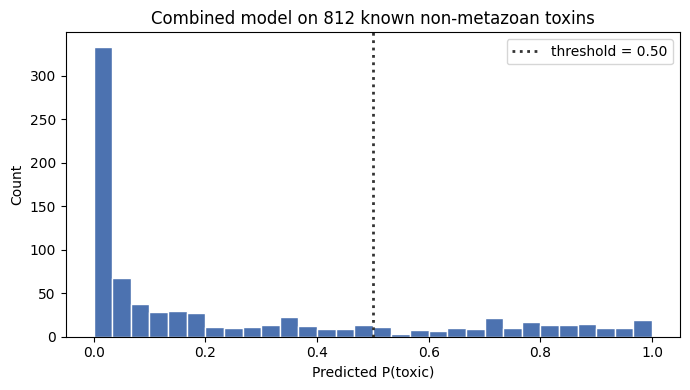

median P(toxic) = 0.07 — most true toxins are scored non-toxic
recall (thr=0.50) = 22%


In [54]:
# P(toxic) distribution for the 812 known non-metazoan toxins
import matplotlib.pyplot as plt

p = non_metazoan_df["p_toxic"]
recall_050 = (p >= 0.5).mean()       # fraction flagged toxic at 0.5

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(p, bins=30, color="#4C72B0", edgecolor="white")

ax.axvline(0.5, color="#333333", ls=":", lw=2,
            label=f"threshold = 0.50")
ax.set_xlabel("Predicted P(toxic)")
ax.set_ylabel("Count")
ax.set_title(f"Combined model on {len(p)} known non-metazoan toxins")
ax.legend()
fig.tight_layout()
plt.show()

print(f"median P(toxic) = {p.median():.2f} — most true toxins are scored non-toxic")
print(f"recall (thr=0.50) = {recall_050:.0%}")

### Takeaway

The combined model **cannot yet reliably indicate toxicity in non-metazoan proteins**: median P(toxic) is ~0.07 and it flags only ~22% (thr 0.5) of *known* non-metazoan toxins. The taxonomy branch is inactive out-of-kingdom (all 812 organisms fall outside the 50 metazoan taxa), and the sequences are out-of-distribution.

This motivates future work rather than an application claim: **adding non-metazoan toxins (and non-toxins) to training, fine-tuning / domain adaptation, and expanding the taxonomy vocabulary beyond metazoa**.

## Unreviewed
(keyword:KW-0800) AND (reviewed:false) AND (taxonomy_id:33208) AND (fragment:false) AND (date_created:[* TO 2026-06-10])

```bash
uv run toxfam predict unreviewed \
  --model-dir model/model_output/combined_run \
  -o benchmark/unreviewed/predict/combined.tsv
```

In [55]:
unreviewed_df = pd.read_csv("../benchmark/unreviewed/predict/combined.tsv", sep='\t')
unreviewed_input = pd.read_csv("../data/evaluation/unreviewed/unreviewed.tsv", sep='\t')

print("Input columns: ",unreviewed_input.columns)
unreviewed_df.head()

Input columns:  Index(['Entry', 'Organism', 'Protein families', 'Sequence', 'Organism (ID)'], dtype='object')


,identifier,pred_1,conf_1,pred_2,conf_2,pred_3,conf_3,p_toxic,predicted_toxic
0,A0A4Y2G8R1,nontox,0.998813,Peptidase S1 family,0.000351,Venom metalloproteinase (M12B) family,0.000324,0.001187,False
1,A0A670IWD1,nontox,0.841922,other,0.042451,Insulin family,0.018022,0.158078,False
2,A0A670J0E7,nontox,0.556936,Venom metalloproteinase (M12B) family,0.414533,Disintegrin family,0.009423,0.443064,True
3,A0A670K065,other,0.939281,nontox,0.055751,Limacoditoxin family,0.000599,0.944249,True
4,A0A670K3I7,other,0.949134,nontox,0.046272,Limacoditoxin family,0.000560,0.953728,True


In [56]:
# add unreviewed input "Protein families" column as "Uniprot Assignments" right after the identifier column, based on "Entry"
unreviewed_df.insert(1, "Uniprot Assignments", unreviewed_df["identifier"].map(unreviewed_input.set_index("Entry")["Protein families"]))
unreviewed_df.head()

,identifier,Uniprot Assignments,pred_1,conf_1,pred_2,conf_2,pred_3,conf_3,p_toxic,predicted_toxic
0,A0A4Y2G8R1,NOTCH family,nontox,0.998813,Peptidase S1 family,0.000351,Venom metalloproteinase (M12B) family,0.000324,0.001187,False
1,A0A670IWD1,Endothelin/sarafotoxin family,nontox,0.841922,other,0.042451,Insulin family,0.018022,0.158078,False
2,A0A670J0E7,NaN,nontox,0.556936,Venom metalloproteinase (M12B) family,0.414533,Disintegrin family,0.009423,0.443064,True
3,A0A670K065,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.939281,nontox,0.055751,Limacoditoxin family,0.000599,0.944249,True
4,A0A670K3I7,Nucleotide pyrophosphatase/phosphodiesterase f...,other,0.949134,nontox,0.046272,Limacoditoxin family,0.000560,0.953728,True
